<a href="https://colab.research.google.com/github/mkg6573/social_media_impact_on_life_ml_/blob/main/Supervised%20Learning%20Algorithms/XGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Social_media_impact_on_life_Clean_Dataset.csv")

In [3]:
print(df.head())

   Age  Gender Academic_Level  Avg_Daily_Usage_Hours Most_Used_Platform  \
0   21    Male  Undergraduate                    4.0           Facebook   
1   23  Female  Undergraduate                    1.6           LinkedIn   
2   22    Male       Graduate                    4.6          Instagram   
3   18    Male  Undergraduate                    7.0           Snapchat   
4   24  Female    High School                    7.5           Facebook   

  Affects_Academic_Performance  Sleep_Hours_Per_Night  Mental_Health_Score  \
0                           No                    6.7                  6.8   
1                           No                    8.6                  7.6   
2                           No                    6.7                  7.0   
3                          Yes                    5.4                  5.3   
4                          Yes                    5.0                  4.4   

  Overall_Impact  
0        Neutral  
1       Positive  
2        Neutral  
3   

In [4]:
# REMOVE MENTAL HEALTH SCORE COLUMN
df = df.drop("Mental_Health_Score", axis=1)


In [6]:
# ENCODE CATEGORICAL DATA
label_encoders = {}

categorical_columns = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Affects_Academic_Performance",
    "Overall_Impact"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# FEATURES & TARGET
X = df.drop("Overall_Impact", axis=1)

y = df["Overall_Impact"]

In [8]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


n_estimators = 10 --> Accuracy = 0.8944
n_estimators = 20 --> Accuracy = 0.9384
n_estimators = 50 --> Accuracy = 0.9501
n_estimators = 100 --> Accuracy = 0.9589
n_estimators = 150 --> Accuracy = 0.9648
n_estimators = 200 --> Accuracy = 0.9707
n_estimators = 300 --> Accuracy = 0.9677

Best n_estimators : 200
Best Accuracy : 0.9706744868035191


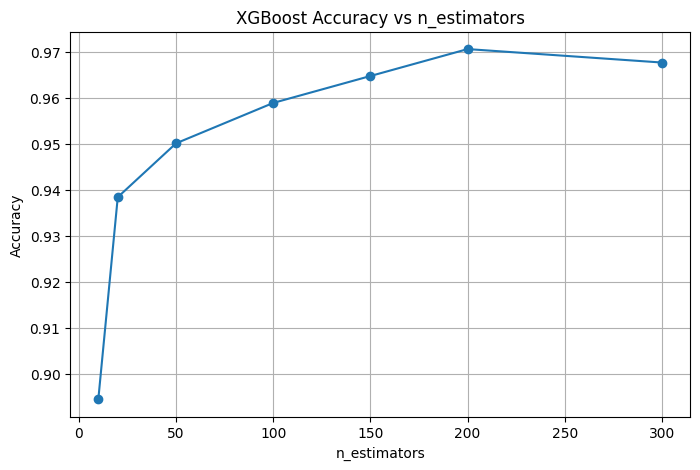

In [15]:
# XGBOOST MODEL
# Different n_estimators values
estimators_list = [10, 20, 50, 100, 150, 200, 300]

# Accuracy store karne ke liye
accuracy_list = []

# Loop
for n in estimators_list:

    # Model create
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=5,
        objective='multi:softmax',
        num_class=3,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store accuracy
    accuracy_list.append(acc)

    # Print result
    print(f"n_estimators = {n} --> Accuracy = {acc:.4f}")


# BEST VALUE

best_accuracy = max(accuracy_list)

best_n = estimators_list[accuracy_list.index(best_accuracy)]

print("\nBest n_estimators :", best_n)
print("Best Accuracy :", best_accuracy)


# GRAPH


plt.figure(figsize=(8,5))

plt.plot(estimators_list, accuracy_list, marker='o')

plt.title("XGBoost Accuracy vs n_estimators")

plt.xlabel("n_estimators")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()


In [16]:
# PREDICTION
y_pred = model.predict(X_test)

In [17]:
# ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)



Accuracy : 0.967741935483871


In [18]:
# CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       197
           1       0.94      0.88      0.91        51
           2       0.98      0.96      0.97        93

    accuracy                           0.97       341
   macro avg       0.96      0.94      0.95       341
weighted avg       0.97      0.97      0.97       341



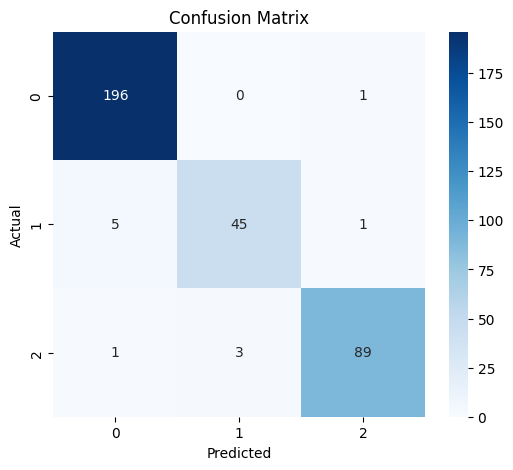

In [19]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

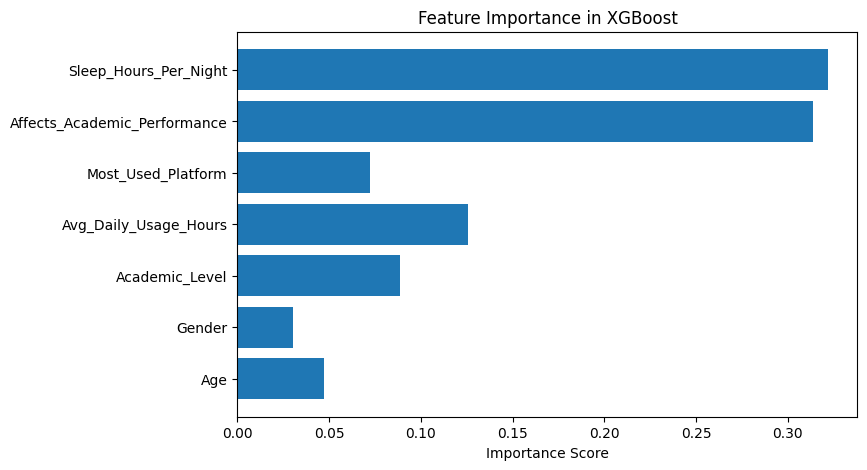

In [20]:
# FEATURE IMPORTANCE
importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,5))

plt.barh(feature_names, importance)

plt.title("Feature Importance in XGBoost")

plt.xlabel("Importance Score")

plt.show()